### 5. V-Plot

In [20]:
import numpy as np
import gzip
import matplotlib.pyplot as plt
from collections import Counter

#### file inputs

In [21]:
# Path to your input data file
input_file = "mapped.bed.gz"

# Initialize lists for X and Y

# Count occurrences (Z) for each (X, Y) pair
z = Counter()

# Read and parse each line to compute X and Y
with gzip.open(input_file, 'rt') as f:
    for line in f:
        parts = line.strip().split('\t')
        # Compute centers
        c1 = (int(parts[2]) + int(parts[3])) / 2
        c2 = (int(parts[8]) + int(parts[9])) / 2
        
        # Calculate X (difference of centers) and Y (fragment length)
        X = int(c2 - c1)
        Y = int(int(parts[9]) - int(parts[8]))
        
        z[(X, Y)] += 1


print("Total unique (X, Y) pairs:", len(z))





Total unique (X, Y) pairs: 280653


In [22]:

# Prepare sorted unique coordinates
unique_x = sorted(set(x for x, y in z))
unique_y = sorted(set(y for x, y in z))

### Plotting Heatmap

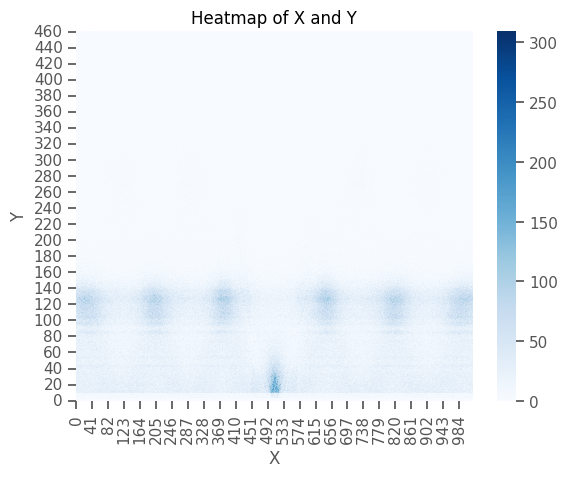

In [23]:

# Create a 2D matrix of counts
matrix = np.zeros((len(unique_y), len(unique_x)))
for i, y in enumerate(unique_y):
    for j, x in enumerate(unique_x):
        matrix[i, j] = z.get((x, y), 0)

# Plot heatmap
sns.heatmap(matrix, cmap='Blues', annot=False, fmt='d')
plt.gca().invert_yaxis()
plt.title('Heatmap of X and Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

plt.show()
